In [1]:
import sys
sys.path.append("..")

import torch
import numpy as np
import json
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from datasets import load_from_disk

from src.data import PROJECT_ROOT, RuleTakerDataset
from src.llm_upgrade import wrap_for_transformer_lens
from src.logit_lens import get_target_token_ids, compute_logit_lens

In [2]:
sns.set_style("whitegrid")

In [3]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/logit_lens"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по анализу logit lens на Pythia-1b

## Эксперимент 3: Pythia-1b + depth-0

In [4]:
EXP_ID = 'exp8-2'
VARIANT = "depth-1"
MODEL_SIZE = "1b"
BASE_MODEL_NAME = "EleutherAI/pythia-1b-deduped"
ADAPTER_PATH = str(PROJECT_ROOT / "results/checkpoints/finetune/exp8-2/checkpoint-1000")
BATCH_SIZE = 32
USE_SMALL = True

In [5]:
model, tokenizer = wrap_for_transformer_lens(
    base_model_name=BASE_MODEL_NAME,
    adapter_path=ADAPTER_PATH,
    device="cuda"
)
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model EleutherAI/pythia-1b-deduped into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-15): 16 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
    

In [6]:
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))
dev_dataset = dataset["dev"]

In [7]:
def add_prompt_to_text(example):
    # Если text уже содержит нужный суффикс, ничего не меняем
    if "The assertion is" in example.get("text", ""):
        return example
    # Иначе собираем из theory + assertion
    theory = example.get("theory", "")
    assertion = example.get("assertion", "")
    example["text"] = f"{theory} {assertion} The assertion is"
    return example

In [8]:
if "The assertion is" not in dev_dataset[0].get("text", ""):
    dev_dataset = dev_dataset.map(add_prompt_to_text)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [9]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 195 токенов (при макс длине 257)


In [10]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [11]:
MAX_LENGTH = max_p95

In [12]:
dev_dataset_wrapped = RuleTakerDataset(dev_dataset, tokenizer, max_length=MAX_LENGTH)
dev_loader = DataLoader(dev_dataset_wrapped, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
torch.cuda.empty_cache()

In [14]:
TRUE_TOKEN_IDS, FALSE_TOKEN_IDS = get_target_token_ids(tokenizer)

In [15]:
results = compute_logit_lens(
    model,
    dev_loader,
    model.cfg.n_layers,
    TRUE_TOKEN_IDS,
    FALSE_TOKEN_IDS,
    device="cuda"
)

In [16]:
dev_accs = results["accs"]
dev_prob_true = results["mean_prob_true"]
dev_prob_false = results["mean_prob_false"]

In [17]:
best_layer = int(np.argmax(dev_accs))
best_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer}, Accuracy: {best_acc:.4f}")

Лучший слой: 8, Accuracy: 0.5260


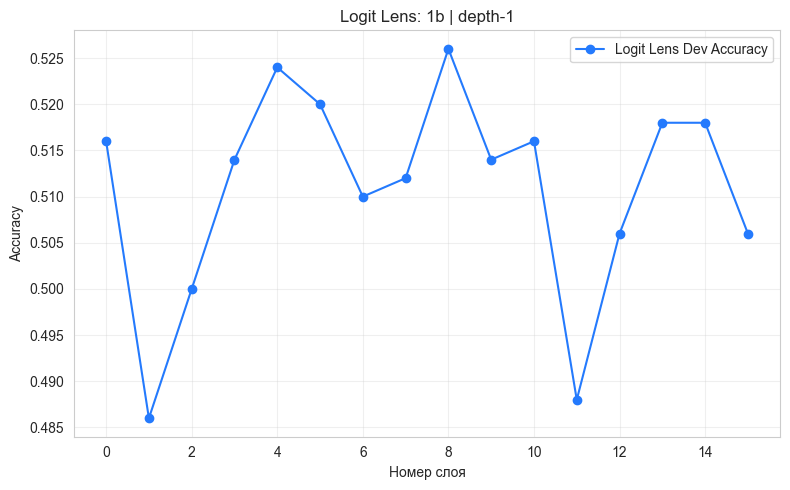

In [18]:
plt.figure(figsize=(8, 5))
x = np.arange(model.cfg.n_layers)
plt.plot(x, dev_accs, marker="o", label="Logit Lens Dev Accuracy", color="xkcd:clear blue")
# plt.axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="Random baseline")
# plt.axvline(best_layer, color="r", linestyle=":", alpha=0.5, label=f"Best layer ({best_layer})")
plt.xlabel("Номер слоя")
plt.ylabel("Accuracy")
plt.title(f"Logit Lens: {MODEL_SIZE} | {VARIANT}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

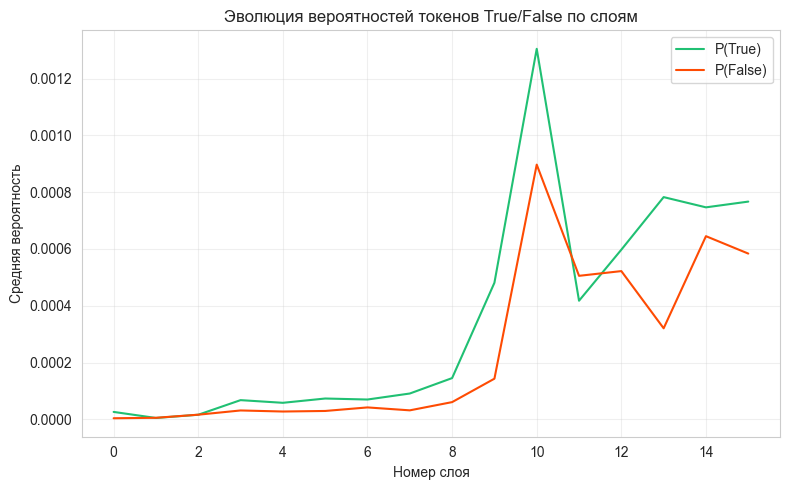

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(x, dev_prob_true, label="P(True)", color="xkcd:dark mint green")
plt.plot(x, dev_prob_false, label="P(False)", color="xkcd:blood orange")
# plt.axvline(best_layer, color="k", linestyle="--", alpha=0.4)
plt.xlabel("Номер слоя")
plt.ylabel("Средняя вероятность")
plt.title("Эволюция вероятностей токенов True/False по слоям")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Сохранение метрик в JSON
fname = f"logit_lens_{MODEL_SIZE}_{VARIANT}_{EXP_ID}.json"
fpath = RESULTS_DIR / fname

metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "best_layer": best_layer,
    "best_dev_acc": float(best_acc),
    "accs": [float(x) for x in results["accs"]],
    "mean_prob_true": [float(x) for x in results["mean_prob_true"]],
    "mean_prob_false": [float(x) for x in results["mean_prob_false"]],
    "mean_abs_diff": [float(x) for x in results["mean_abs_diff"]],
    "mean_confidence": [float(x) for x in results["mean_confidence"]],
    "mean_entropy": [float(x) for x in results["mean_entropy"]],
    "mean_agreement": [float(x) for x in results["mean_agreement"]]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "logit_lens_analysis",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_dev_acc": float(best_acc),
    "n_layers": len(results["accs"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": list(range(len(results["accs"]))),
    "accs": [float(x) for x in results["accs"]],
    "mean_prob_true": [float(x) for x in results["mean_prob_true"]],
    "mean_prob_false": [float(x) for x in results["mean_prob_false"]],
    "mean_abs_diff": [float(x) for x in results["mean_abs_diff"]],
    "mean_confidence": [float(x) for x in results["mean_confidence"]],
    "mean_entropy": [float(x) for x in results["mean_entropy"]],
    "mean_agreement": [float(x) for x in results["mean_agreement"]]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\logit_lens\logit_lens_1b_depth-1_exp8-2.json
